# SEC Risk Classification Baseline

Goal: train a baseline classifier on manually annotated SEC filing paragraphs to predict:
- negative_risk
- neutral
- positive_outlook

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

In [35]:
df = pd.read_csv("../data/annotation_sample.csv")
df = df[df["manual_label"].notna()].copy()

print("Rows:", len(df))
df.head()

Rows: 200


,id,text,weak_label,manual_label
0,167,the company’s business requires it to use and ...,neutral,neutral
1,249,we make significant investments in products an...,positive_outlook,negative_risk
2,85,the company is also currently subject to antit...,negative_risk,negative_risk
3,169,the company experiences malicious attacks and ...,negative_risk,negative_risk
4,188,"the technology industry, including, in some in...",negative_risk,negative_risk


In [36]:
df["manual_label"].value_counts()

manual_label
negative_risk       161
neutral              29
positive_outlook     10
Name: count, dtype: int64

In [37]:
(df["manual_label"].value_counts(normalize=True) * 100).round(2)

manual_label
negative_risk       80.5
neutral             14.5
positive_outlook     5.0
Name: proportion, dtype: float64

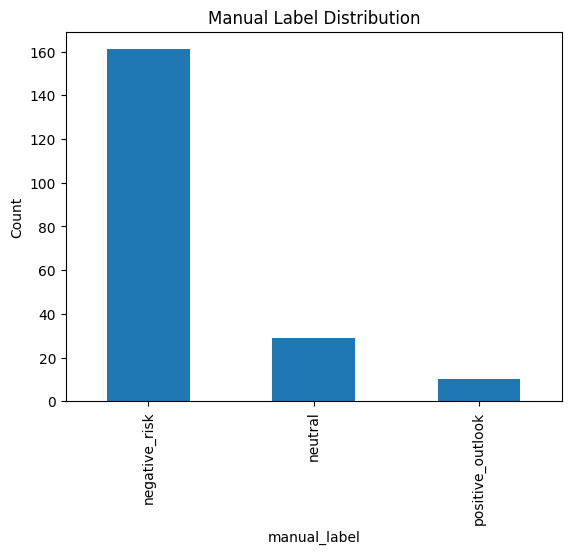

In [38]:
df["manual_label"].value_counts().plot(kind="bar")
plt.title("Manual Label Distribution")
plt.ylabel("Count")
plt.show()

In [39]:
label_map = {
    "negative_risk": 0,
    "neutral": 1,
    "positive_outlook": 2
}

inverse_label_map = {v: k for k, v in label_map.items()}

df["label"] = df["manual_label"].map(label_map)
df[["manual_label", "label"]].head()

,manual_label,label
0,neutral,1
1,negative_risk,0
2,negative_risk,0
3,negative_risk,0
4,negative_risk,0


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 160
Test size: 40


In [41]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Train matrix shape:", X_train_vec.shape)
print("Test matrix shape:", X_test_vec.shape)

Train matrix shape: (160, 1774)
Test matrix shape: (40, 1774)


In [42]:
model = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [43]:
preds = model.predict(X_test_vec)

print("Accuracy:", round(accuracy_score(y_test, preds), 4))
print()
print(classification_report(
    y_test,
    preds,
    target_names=["negative_risk", "neutral", "positive_outlook"]
))

Accuracy: 0.825

                  precision    recall  f1-score   support

   negative_risk       0.93      0.88      0.90        32
         neutral       0.56      0.83      0.67         6
positive_outlook       0.00      0.00      0.00         2

        accuracy                           0.82        40
       macro avg       0.50      0.57      0.52        40
    weighted avg       0.83      0.82      0.82        40



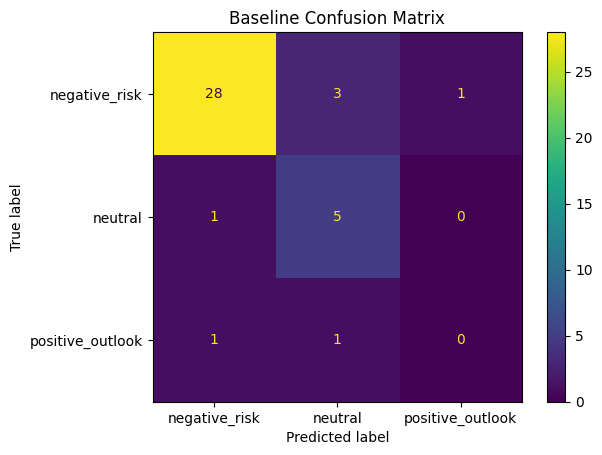

In [44]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative_risk", "neutral", "positive_outlook"]
)
disp.plot()
plt.title("Baseline Confusion Matrix")
plt.show()

In [45]:
results = pd.DataFrame({
    "text": X_test.values,
    "true_label": [inverse_label_map[y] for y in y_test],
    "pred_label": [inverse_label_map[p] for p in preds]
})

mistakes = results[results["true_label"] != results["pred_label"]].copy()
print("Mistakes:", len(mistakes))
mistakes.head(15)

Mistakes: 7


,text,true_label,pred_label
3,the company has international operations with ...,positive_outlook,neutral
7,the company distributes its products and certa...,neutral,negative_risk
12,the company’s operations and performance depen...,negative_risk,neutral
13,the company’s business is subject to a variety...,negative_risk,neutral
15,the company distributes third-party applicatio...,negative_risk,neutral
16,continuing to enhance the attractiveness of ou...,positive_outlook,negative_risk
30,our increasing focus on cloud-based services p...,negative_risk,positive_outlook


In [46]:
feature_names = vectorizer.get_feature_names_out()

for class_index, class_name in enumerate(["negative_risk", "neutral", "positive_outlook"]):
    top_ids = np.argsort(model.coef_[class_index])[-15:]
    print(f"\nTop words for {class_name}:")
    print([feature_names[i] for i in top_ids])


Top words for negative_risk:
['information', 'affect', 'foreign', 'impact', 'certain', 'value', 'margins', 'business', 'tax', 'adversely', 'content', 'significant', 'company', 'new', 'products']

Top words for neutral:
['fluctuate', 'item', 'net', 'software', 'store', 'remain', 'quarterly', 'performance', 'expects', 'data', 'company', 'outside', 'future', 'results', 'depends']

Top words for positive_outlook:
['functions', 'productivity', 'engineering', 'practices', 'policies', 'effectively', 'effectiveness', 'sustain', 'adequate', 'based', 'capacity', 'datacenter', 'operations', 'devices', 'cloud']


In [47]:
pd.crosstab(df["weak_label"], df["manual_label"], margins=True)

manual_label,negative_risk,neutral,positive_outlook,All
weak_label,,,,
negative_risk,108,6,0,114
neutral,14,9,4,27
positive_outlook,39,14,6,59
All,161,29,10,200


In [48]:
weak_acc = (df["weak_label"] == df["manual_label"]).mean()
print("Weak label agreement with manual labels:", round(weak_acc, 4))

Weak label agreement with manual labels: 0.615


In [49]:
import os
import pickle

os.makedirs("../models", exist_ok=True)

with open("../models/risk_baseline.pkl", "wb") as f:
    pickle.dump((model, vectorizer, label_map), f)